In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:,.2f}'.format)

In [99]:
df = pd.read_csv("sales_random.csv")

In [100]:
df.head()

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
0,245750,146517_8.0502.245_BUD.127_LOK,"752,024.00","15,788.87",6,2,mieszkalna,PLN,47.63,2025-04-16,Ulica Instalatorów 7A,Warszawa
1,245746,146517_8.0502.245_BUD.68_LOK,"545,000.00","14,379.95",2,2,mieszkalna,PLN,37.90,2025-04-16,Ulica Instalatorów 7A,Warszawa
2,245751,146517_8.0502.245_BUD.94_LOK,"657,359.50","17,163.43",7,2,mieszkalna,PLN,38.30,2025-04-16,Ulica Instalatorów 7A,Warszawa
3,242913,146517_8.0826.117_BUD.58_LOK,"855,942.85","14,306.25",3,3,mieszkalna,PLN,59.83,2025-04-16,Aleje Jerozolimskie 190,Warszawa
4,241286,146514_8.1145.111_BUD.82_LOK,"598,424.89","11,521.46",3,3,mieszkalna,PLN,51.94,2025-04-16,Ulica Mieczysława Pożaryskiego 35A,Warszawa


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_rcn_id    2500 non-null   int64  
 1   name           2500 non-null   object 
 2   amount         2500 non-null   float64
 3   amount_sqm     2500 non-null   float64
 4   floor_number   2500 non-null   int64  
 5   rooms_number   2500 non-null   int64  
 6   type           2500 non-null   object 
 7   currency       2500 non-null   object 
 8   size           2500 non-null   float64
 9   creation_date  2500 non-null   object 
 10  invest_name    2500 non-null   object 
 11  invest_city    2500 non-null   object 
dtypes: float64(3), int64(3), object(6)
memory usage: 234.5+ KB


In [102]:
df['type'].value_counts()

type
mieszkalna    2500
Name: count, dtype: int64

In [103]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"2,500.00","2,500.00","2,500.00","2,500.00","2,500.00","2,500.00"
mean,"156,672.83","1,881,912.15","28,384.37",3.94,2.74,57.59
std,"55,702.61","11,836,597.84","168,256.96",2.59,1.20,25.68
min,"52,087.00","35,000.00",528.94,0.00,0.00,20.13
25%,"110,919.00","409,341.95","8,319.80",2.00,2.00,40.60
50%,"160,508.00","565,000.00","10,680.33",3.00,3.00,51.01
75%,"201,987.25","769,000.00","14,138.56",5.00,3.00,67.70
max,"259,752.00","183,982,922.19","3,001,352.73",30.00,10.00,247.54


In [104]:
df[df['amount_sqm']==df['amount_sqm'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
823,86541,146510_8.0308.41.2_BUD.122_LOK,"183,982,922.19","3,001,352.73",13,2,mieszkalna,PLN,61.30,2017-07-21,Ulica Złota 44,Warszawa


In [105]:
df[df['amount']==df['amount'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
822,86545,146510_8.0308.41.2_BUD.121_LOK,"183,982,922.19","861,343.27",13,4,mieszkalna,PLN,213.60,2017-07-21,Ulica Złota 44,Warszawa
823,86541,146510_8.0308.41.2_BUD.122_LOK,"183,982,922.19","3,001,352.73",13,2,mieszkalna,PLN,61.30,2017-07-21,Ulica Złota 44,Warszawa
824,86542,146510_8.0308.41.2_BUD.123_LOK,"183,982,922.19","2,996,464.53",13,2,mieszkalna,PLN,61.40,2017-07-21,Ulica Złota 44,Warszawa


In [106]:
df[df['size']==df['size'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
273,55884,146510_8.0603.21/4.2_BUD.10_LOK,"10,200,000.00","41,205.46",5,3,mieszkalna,PLN,247.54,2018-10-15,Ulica Wioślarska 10,Warszawa


In [ ]:
kolumny = ['amount','amount_sqm','size']
for i in kolumny:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

df = df = df[df['rooms_number'] != 0]

In [108]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size
count,"2,222.00","2,222.00","2,222.00","2,222.00","2,222.00","2,222.00"
mean,"155,919.80","564,366.71","11,040.33",3.91,2.62,52.31
std,"55,326.66","229,924.32","3,634.42",2.49,1.06,16.70
min,"52,087.00","35,000.00",528.94,0.00,0.00,20.13
25%,"110,911.00","390,000.00","8,199.57",2.00,2.00,39.60
50%,"159,882.50","525,000.00","10,390.53",3.00,3.00,49.08
75%,"199,584.00","692,608.50","13,398.49",5.00,3.00,63.34
max,"259,752.00","1,306,962.44","21,303.60",17.00,7.00,102.20


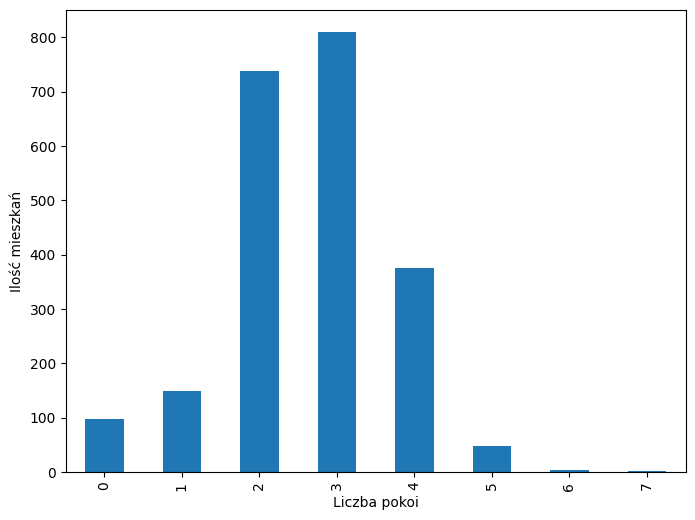

rooms_number
3    810
2    738
4    375
1    149
0     98
5     48
6      3
7      1
Name: count, dtype: int64

In [109]:
df['rooms_number'].value_counts().sort_index().plot(kind='bar', figsize=(8,6))
plt.xlabel('Liczba pokoi')
plt.ylabel('Ilość mieszkań')
plt.show()
df["rooms_number"].value_counts()

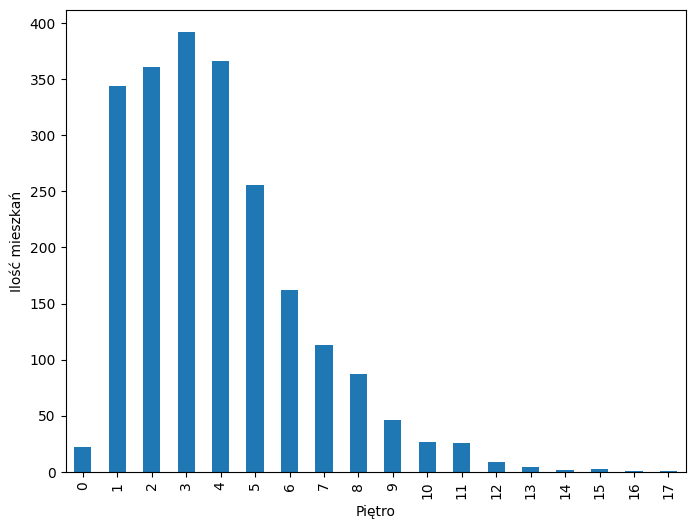

floor_number
3     392
4     366
2     361
1     344
5     256
6     162
7     113
8      87
9      46
10     27
11     26
0      22
12      9
13      4
15      3
14      2
16      1
17      1
Name: count, dtype: int64

In [110]:
df['floor_number'].value_counts().sort_index().plot(kind='bar', figsize=(8,6))
plt.xlabel('Piętro')
plt.ylabel('Ilość mieszkań')
plt.show()
df["floor_number"].value_counts()

<Axes: >

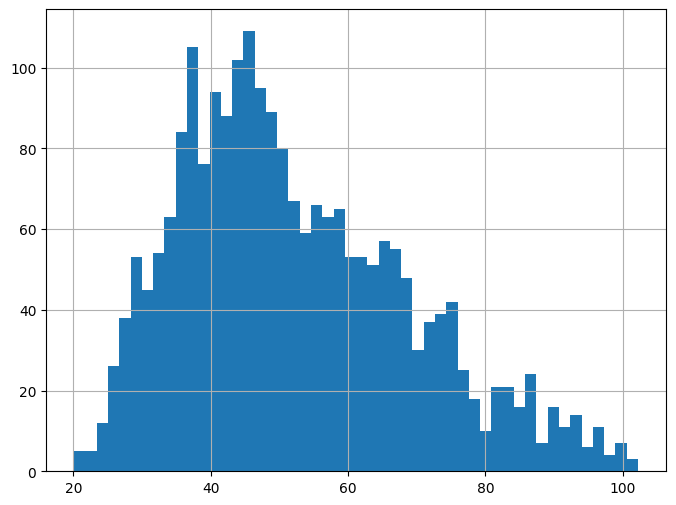

In [111]:
plt.figure(figsize=(8,6))
df["size"].hist(bins=50)


<Axes: >

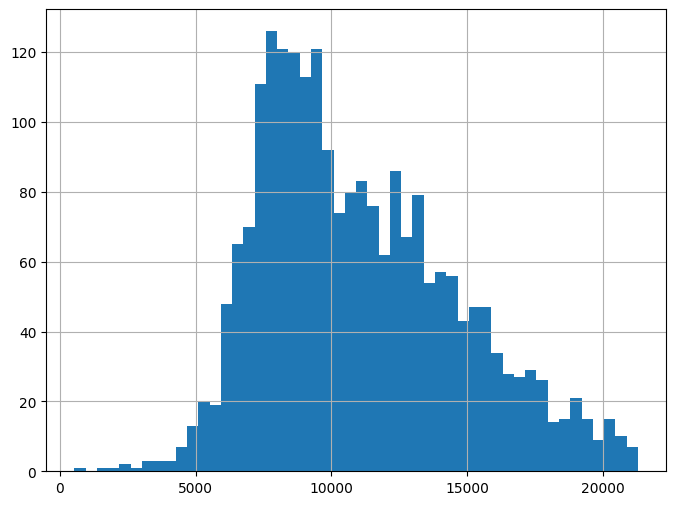

In [112]:
plt.figure(figsize=(8,6))
df["amount_sqm"].hist(bins=50)


In [113]:
gb = df.groupby('rooms_number')['amount_sqm'].mean()
print(gb)

rooms_number
0   11,823.04
1   12,380.67
2   11,751.64
3   10,631.50
4    9,976.21
5    9,820.38
6    9,014.75
7    4,525.22
Name: amount_sqm, dtype: float64


In [114]:
df[df['rooms_number']==0]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city
133,168151,146503_8.1610.50/8.1_BUD.10_LOK,"368,566.78","8,042.04",1,0,mieszkalna,PLN,45.83,2022-04-01,Ulica Przejezdna 9,Warszawa
134,166276,146505_8.0526.1036_BUD.8_LOK,"689,112.37","9,269.74",3,0,mieszkalna,PLN,74.34,2022-04-01,Ulica Santocka 8,Warszawa
135,173144,146507_8.0416.132.3_BUD.2_LOK,"511,289.00","8,984.17",1,0,mieszkalna,PLN,56.91,2022-04-01,Ulica Roztocka 5,Warszawa
136,172413,146507_8.0416.132.3_BUD.9_LOK,"262,666.00","8,820.21",2,0,mieszkalna,PLN,29.78,2022-04-01,Ulica Roztocka 5,Warszawa
474,213966,146518_8.0502.12/15.1_BUD.193_LOK,"1,078,544.49","15,601.69",3,0,mieszkalna,PLN,69.13,2023-11-28,Ulica Kacpra Karlińskiego 4,Warszawa
...,...,...,...,...,...,...,...,...,...,...,...,...
2162,173909,146505_8.0537.1145_BUD.177_LOK,"415,000.00","14,779.20",6,0,mieszkalna,PLN,28.08,2022-05-27,Ulica Nałęczowska 33,Warszawa
2364,159485,146511_8.0929.1/7.1_BUD.7_LOK,"500,000.00","12,315.27",1,0,mieszkalna,PLN,40.60,2022-03-03,Ulica Ludwika Kondratowicza 22,Warszawa
2391,170979,146505_8.0804.1085_BUD.61_LOK,"361,738.50","14,146.99",7,0,mieszkalna,PLN,25.57,2022-06-24,Ulica Domaniewska 26,Warszawa
2392,206152,146516_8.0622.9.11_BUD.143_LOK,"703,252.09","15,288.09",3,0,mieszkalna,PLN,46.00,2022-06-24,Ulica Syta 94J,Warszawa
